# Scientific Figure: Model-to-Model Comparisons
## Snow Depth Time Series Comparison (2024–2025 Season)

**Purpose:** Create a publication-quality figure for Section 4.1 comparing SNOWPACK, FSM2, and seNorge snow depth at 4 representative virtual stations in Jotunheimen.

**Models compared:**
- SNOWPACK (benchmark)
- FSM2
- seNorge

**Period:** 1 September 2024 – 31 May 2025

In [1]:
import json
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load Virtual Station Metadata

In [2]:
# Load SNOWPACK virtual station metadata
with open("../data/SNOWPACK/vstations.json") as f:
    stations_meta = json.load(f)

# Select 4 representative stations with good elevation spread
selected_stations = ["VIR6A", "VIR1A", "VIR2A", "VIR10A"]

# Create metadata dict for selected stations
station_info = {}
for station_id in selected_stations:
    if station_id in stations_meta:
        info = stations_meta[station_id]
        station_info[station_id] = {
            'elev': info['elev'],
            'lat': info['lat'],
            'lon': info['lon']
        }

# Sort by elevation for display
station_info_sorted = dict(sorted(station_info.items(), key=lambda x: x[1]['elev']))

print("Selected stations:")
for sid, info in station_info_sorted.items():
    print(f"  {sid}: {info['elev']:.0f} m")

Selected stations:
  VIR6A: 1031 m
  VIR1A: 1410 m
  VIR10A: 1668 m
  VIR2A: 1687 m


## 2. Load SNOWPACK Data

In [3]:
def read_snowpack_smet(filepath):
    """
    Read SNOWPACK .smet file and return pandas DataFrame
    """
    with open(filepath, "r") as f:
        lines = f.readlines()
    
    # Find field names from header
    fields_line = [line for line in lines if line.startswith("fields")][0]
    colnames = fields_line.split("=", 1)[1].strip().split()
    
    # Find where data starts
    data_start = [i for i, line in enumerate(lines) if line.strip() == "[DATA]"][0] + 1
    
    # Read data
    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=data_start,
        names=colnames,
        na_values=-999
    )
    
    # Convert timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    
    # Convert HS_mod from cm to m
    if "HS_mod" in df.columns:
        df["HS_mod_m"] = df["HS_mod"] / 100.0
    
    return df

# Load SNOWPACK data for selected stations
snowpack_data = {}
for station_id in selected_stations:
    filepath = f"../data/SNOWPACK/smet/{station_id}.smet"
    try:
        df = read_snowpack_smet(filepath)
        snowpack_data[station_id] = df
        print(f"{station_id}: {len(df)} records, {df['timestamp'].min()} to {df['timestamp'].max()}")
    except FileNotFoundError:
        print(f"Warning: {filepath} not found")
    except Exception as e:
        print(f"Error reading {station_id}: {e}")

VIR6A: 6575 records, 2024-09-01 01:00:00 to 2025-06-01 23:00:00
VIR1A: 6575 records, 2024-09-01 01:00:00 to 2025-06-01 23:00:00
VIR2A: 6575 records, 2024-09-01 01:00:00 to 2025-06-01 23:00:00
VIR10A: 6575 records, 2024-09-01 01:00:00 to 2025-06-01 23:00:00


## 3. Load FSM2 Data

In [4]:
# Load FSM2 netCDF files for 2024 and 2025
fsm2_files = [
    "../data/FSM2/fsm2_sd_2024.nc",
    "../data/FSM2/fsm2_sd_2025.nc"
]

fsm2_datasets = []
for f in fsm2_files:
    if os.path.exists(f):
        ds = xr.open_dataset(f)
        fsm2_datasets.append(ds)
        print(f"Loaded: {f}")
        print(f"  Time range: {ds['time'].values[0]} to {ds['time'].values[-1]}")
        print(f"  Dims: {ds.dims}")
    else:
        print(f"File not found: {f}")

# Concatenate along time dimension
if fsm2_datasets:
    fsm2_concat = xr.concat(fsm2_datasets, dim='time')
    fsm2_concat = fsm2_concat.sortby('time')
    print(f"\nConcatenated FSM2: {fsm2_concat['time'].values[0]} to {fsm2_concat['time'].values[-1]}")

Loaded: ../data/FSM2/fsm2_sd_2024.nc
  Time range: 2024-01-01T00:00:00.000000000 to 2024-12-31T00:00:00.000000000
  Dims: FrozenMappingWarningOnValuesAccess({'time': 366, 'y': 1550, 'x': 1195})
Loaded: ../data/FSM2/fsm2_sd_2025.nc
  Time range: 2025-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
  Dims: FrozenMappingWarningOnValuesAccess({'time': 365, 'y': 1550, 'x': 1195})

Concatenated FSM2: 2024-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000


In [8]:
# Inspect FSM2 structure
print("FSM2 Dataset structure:")
print(fsm2_concat)
print("\nCoordinates:")
print(list(fsm2_concat.coords.keys()))
print("\nData variables:")
print(list(fsm2_concat.data_vars.keys()))

FSM2 Dataset structure:
<xarray.Dataset> Size: 5GB
Dimensions:      (time: 731, y: 1550, x: 1195)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2024-01-01 2024-01-02 ... 2025-12-31
  * y            (y) float64 12kB 6.45e+06 6.451e+06 ... 7.998e+06 7.999e+06
  * x            (x) float64 10kB -7.5e+04 -7.4e+04 ... 1.118e+06 1.119e+06
    lon          (y, x) float64 15MB 5.301 5.317 5.334 5.35 ... 32.44 32.47 32.5
    lat          (y, x) float64 15MB 57.82 57.82 57.82 ... 71.29 71.28 71.28
Data variables:
    snow_depth   (time, y, x) float32 5GB nan nan nan nan ... nan nan nan nan
    UTM_Zone_33  (time) float64 6kB 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
Attributes:
    title:        Snow depth
    institution:  NVE
    source:       ConvertTo-Grid
    history:      Initial
    references:   http://www.xgeo.no/
    comment:      Snow depth simulated by the FSM2 model run at NVE and force...
    Conventions:  CF-1.6

Coordinates:
['time', 'y', 'x', 'lon', 'lat']

Data varia

## 4. Load seNorge Data

In [5]:
# Load seNorge netCDF files for 2024 and 2025
senorge_files = [
    "../data/seNorge/sd_2024.nc",
    "../data/seNorge/sd_2025.nc"
]

senorge_datasets = []
for f in senorge_files:
    if os.path.exists(f):
        ds = xr.open_dataset(f)
        senorge_datasets.append(ds)
        print(f"Loaded: {f}")
        print(f"  Time range: {ds['time'].values[0]} to {ds['time'].values[-1]}")
        print(f"  Dims: {ds.dims}")
    else:
        print(f"File not found: {f}")

# Concatenate along time dimension
if senorge_datasets:
    senorge_concat = xr.concat(senorge_datasets, dim='time')
    senorge_concat = senorge_concat.sortby('time')
    print(f"\nConcatenated seNorge: {senorge_concat['time'].values[0]} to {senorge_concat['time'].values[-1]}")

Loaded: ../data/seNorge/sd_2024.nc
  Time range: 2024-01-01T00:00:00.000000000 to 2024-12-31T00:00:00.000000000
  Dims: FrozenMappingWarningOnValuesAccess({'time': 366, 'y': 1550, 'x': 1195})
Loaded: ../data/seNorge/sd_2025.nc
  Time range: 2025-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
  Dims: FrozenMappingWarningOnValuesAccess({'time': 365, 'y': 1550, 'x': 1195})

Concatenated seNorge: 2024-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000


## 5. Extract Data at Station Locations

In [9]:
# Extract FSM2 data at station locations
# FSM2 uses y,x coordinates in UTM Zone 33, with lat/lon as 2D coordinate arrays
fsm2_extracted = {}

for station_id in selected_stations:
    if station_id in station_info:
        lat = station_info[station_id]['lat']
        lon = station_info[station_id]['lon']
        
        try:
            # Get lat and lon 2D arrays
            fsm2_lat = fsm2_concat['lat'].values
            fsm2_lon = fsm2_concat['lon'].values
            
            # Find nearest grid point by computing distances
            distances = np.sqrt((fsm2_lat - lat)**2 + (fsm2_lon - lon)**2)
            y_idx, x_idx = np.unravel_index(distances.argmin(), distances.shape)
            
            # Extract snow depth at nearest grid point
            sd = fsm2_concat['snow_depth'].values[:, y_idx, x_idx]
            
            # Check if data is in mm or m (FSM2 typically outputs in mm)
            if np.nanmax(sd) > 10:  # If max > 10, likely mm
                sd = sd / 1000.0
            
            time = fsm2_concat['time'].values
            
            fsm2_extracted[station_id] = pd.DataFrame({
                'time': pd.to_datetime(time),
                'snow_depth_m': sd
            })
            fsm2_extracted[station_id] = fsm2_extracted[station_id].sort_values('time')
            print(f"{station_id}: FSM2 extracted, max SD = {np.nanmax(sd):.2f} m")
            
        except Exception as e:
            print(f"Error extracting FSM2 for {station_id}: {e}")

print("\nFSM2 data extracted for all stations")

VIR6A: FSM2 extracted, max SD = 2.84 m
VIR1A: FSM2 extracted, max SD = 3.79 m
VIR2A: FSM2 extracted, max SD = 4.18 m
VIR10A: FSM2 extracted, max SD = 4.90 m

FSM2 data extracted for all stations


In [10]:
# Extract seNorge data at station locations
# seNorge also has 2D lat/lon coordinates
senorge_extracted = {}

for station_id in selected_stations:
    if station_id in station_info:
        lat = station_info[station_id]['lat']
        lon = station_info[station_id]['lon']
        
        try:
            # Get lat and lon 2D arrays
            senorge_lat = senorge_concat['lat'].values
            senorge_lon = senorge_concat['lon'].values
            
            # Find nearest grid point by computing distances
            distances = np.sqrt((senorge_lat - lat)**2 + (senorge_lon - lon)**2)
            y_idx, x_idx = np.unravel_index(distances.argmin(), distances.shape)
            
            # Extract snow depth at nearest grid point
            sd = senorge_concat['snow_depth'].values[:, y_idx, x_idx]
            
            # Check if data is in cm or m
            if np.nanmax(sd) > 10:  # If max > 10, likely cm
                sd = sd / 100.0
            
            time = senorge_concat['time'].values
            
            senorge_extracted[station_id] = pd.DataFrame({
                'time': pd.to_datetime(time),
                'snow_depth_m': sd
            })
            senorge_extracted[station_id] = senorge_extracted[station_id].sort_values('time')
            print(f"{station_id}: seNorge extracted, max SD = {np.nanmax(sd):.2f} m")
            
        except Exception as e:
            print(f"Error extracting seNorge for {station_id}: {e}")

print("\nseNorge data extracted for all stations")

VIR6A: seNorge extracted, max SD = 3.12 m
VIR1A: seNorge extracted, max SD = 4.03 m
VIR2A: seNorge extracted, max SD = 4.56 m
VIR10A: seNorge extracted, max SD = 4.51 m

seNorge data extracted for all stations


## 6. Filter to Time Period: 1 Sep 2024 – 31 May 2025

In [11]:
# Define time period
start_date = pd.Timestamp('2024-09-01')
end_date = pd.Timestamp('2025-05-31')

print(f"Filtering data to: {start_date.date()} – {end_date.date()}")

# Filter all datasets
for station_id in selected_stations:
    # SNOWPACK
    if station_id in snowpack_data:
        mask = (snowpack_data[station_id]['timestamp'] >= start_date) & \
               (snowpack_data[station_id]['timestamp'] <= end_date)
        snowpack_data[station_id] = snowpack_data[station_id][mask].reset_index(drop=True)
        print(f"{station_id} SNOWPACK: {len(snowpack_data[station_id])} records")
    
    # FSM2
    if station_id in fsm2_extracted:
        mask = (fsm2_extracted[station_id]['time'] >= start_date) & \
               (fsm2_extracted[station_id]['time'] <= end_date)
        fsm2_extracted[station_id] = fsm2_extracted[station_id][mask].reset_index(drop=True)
        print(f"{station_id} FSM2: {len(fsm2_extracted[station_id])} records")
    
    # seNorge
    if station_id in senorge_extracted:
        mask = (senorge_extracted[station_id]['time'] >= start_date) & \
               (senorge_extracted[station_id]['time'] <= end_date)
        senorge_extracted[station_id] = senorge_extracted[station_id][mask].reset_index(drop=True)
        print(f"{station_id} seNorge: {len(senorge_extracted[station_id])} records")

Filtering data to: 2024-09-01 – 2025-05-31
VIR6A SNOWPACK: 6528 records
VIR6A FSM2: 273 records
VIR6A seNorge: 273 records
VIR1A SNOWPACK: 6528 records
VIR1A FSM2: 273 records
VIR1A seNorge: 273 records
VIR2A SNOWPACK: 6528 records
VIR2A FSM2: 273 records
VIR2A seNorge: 273 records
VIR10A SNOWPACK: 6528 records
VIR10A FSM2: 273 records
VIR10A seNorge: 273 records


## 7. Create Publication-Quality Figure

Figure created successfully


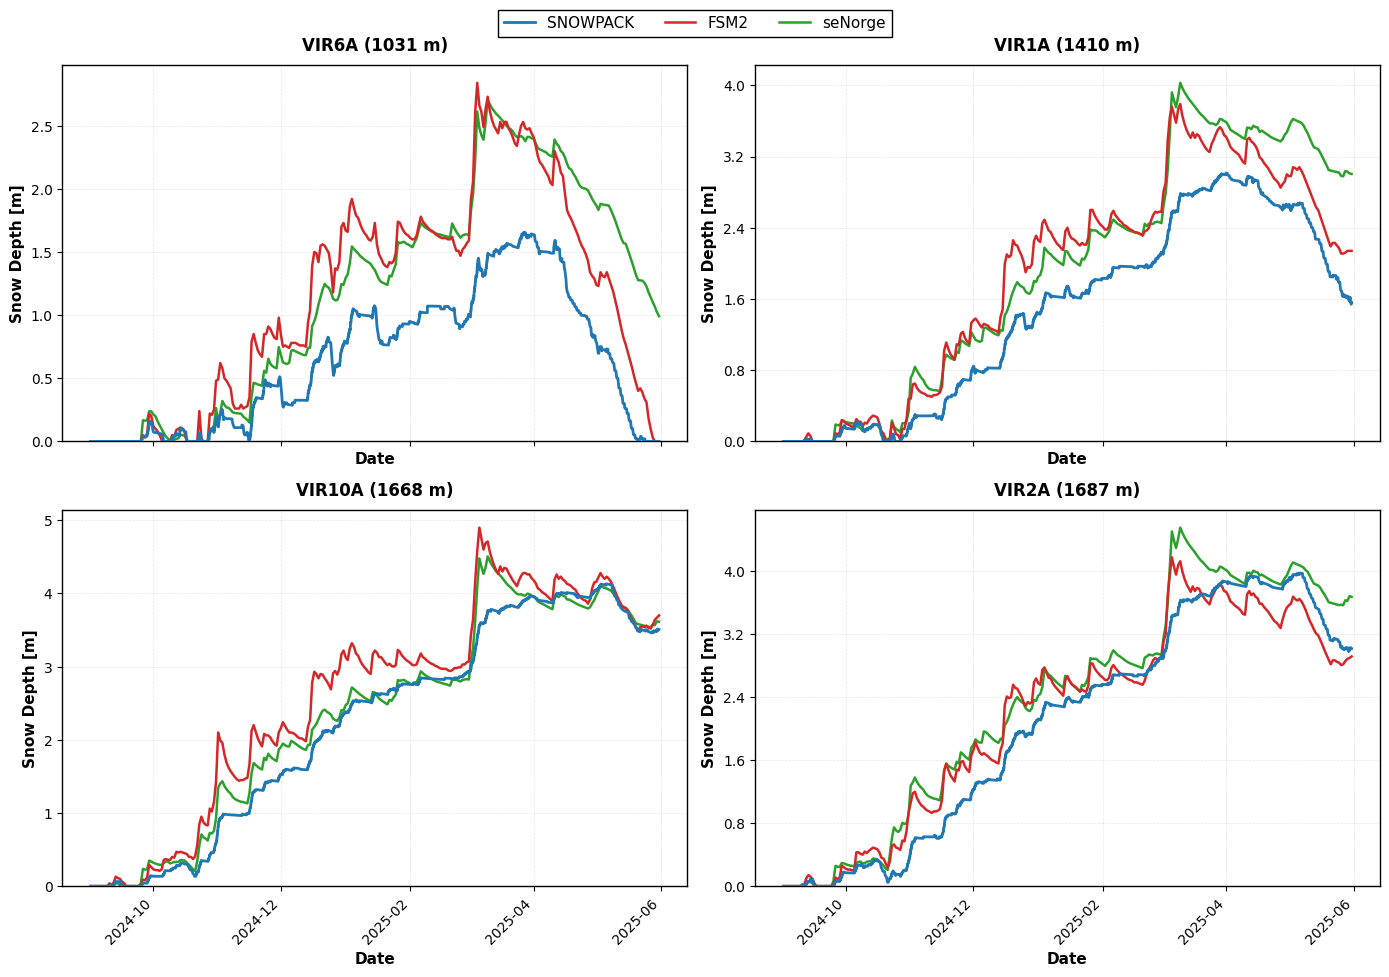

In [12]:
# Define consistent colors for each model
model_colors = {
    'SNOWPACK': '#1f77b4',    # Blue
    'FSM2': '#d62728',        # Red
    'seNorge': '#2ca02c'      # Green
}

model_linewidth = {
    'SNOWPACK': 2.0,
    'FSM2': 1.8,
    'seNorge': 1.8
}

# Create figure with 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor('white')

# Sort selected_stations by elevation for display
selected_sorted = sorted(selected_stations, key=lambda x: station_info[x]['elev'])

# Plot data for each station
for idx, station_id in enumerate(selected_sorted):
    ax = axes[idx // 2, idx % 2]
    elev = station_info[station_id]['elev']
    
    # Plot each model
    # SNOWPACK
    if station_id in snowpack_data and len(snowpack_data[station_id]) > 0:
        ax.plot(
            snowpack_data[station_id]['timestamp'],
            snowpack_data[station_id]['HS_mod_m'],
            color=model_colors['SNOWPACK'],
            linewidth=model_linewidth['SNOWPACK'],
            label='SNOWPACK',
            zorder=3
        )
    
    # FSM2
    if station_id in fsm2_extracted and len(fsm2_extracted[station_id]) > 0:
        ax.plot(
            fsm2_extracted[station_id]['time'],
            fsm2_extracted[station_id]['snow_depth_m'],
            color=model_colors['FSM2'],
            linewidth=model_linewidth['FSM2'],
            label='FSM2',
            zorder=2
        )
    
    # seNorge
    if station_id in senorge_extracted and len(senorge_extracted[station_id]) > 0:
        ax.plot(
            senorge_extracted[station_id]['time'],
            senorge_extracted[station_id]['snow_depth_m'],
            color=model_colors['seNorge'],
            linewidth=model_linewidth['seNorge'],
            label='seNorge',
            zorder=1
        )
    
    # Styling
    ax.set_facecolor('white')
    ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    # Labels
    ax.set_ylabel('Snow Depth [m]', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11, fontweight='bold')
    
    # Title with station ID and elevation
    ax.set_title(f'{station_id} ({elev:.0f} m)', fontsize=12, fontweight='bold', pad=10)
    
    # Format x-axis
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Every 2 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Y-axis formatting
    ax.yaxis.set_major_locator(MaxNLocator(6))
    
    # Set reasonable y-axis limits
    ax.set_ylim(bottom=0)
    
    # Spine styling
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
    
    # Tick styling
    ax.tick_params(labelsize=10)

# Create shared legend
handles = [
    plt.Line2D([0], [0], color=model_colors['SNOWPACK'], linewidth=model_linewidth['SNOWPACK'], label='SNOWPACK'),
    plt.Line2D([0], [0], color=model_colors['FSM2'], linewidth=model_linewidth['FSM2'], label='FSM2'),
    plt.Line2D([0], [0], color=model_colors['seNorge'], linewidth=model_linewidth['seNorge'], label='seNorge')
]

fig.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=11,
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=1.0,
    edgecolor='black'
)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

print("Figure created successfully")
plt.show()

## 8. Save Figure in Multiple Formats

In [13]:
# Create output directory if it doesn't exist
output_dir = "../figures_thesis"
os.makedirs(output_dir, exist_ok=True)

# Define figure filename
figure_name = "Fig_04_1_model_comparison_timeseries"

# Save as PDF (for Overleaf)
pdf_path = os.path.join(output_dir, f"{figure_name}.pdf")
fig.savefig(pdf_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"Saved PDF: {pdf_path}")

# Save as PNG (for preview/screen)
png_path = os.path.join(output_dir, f"{figure_name}.png")
fig.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"Saved PNG: {png_path}")

# Save as SVG (for potential editing)
svg_path = os.path.join(output_dir, f"{figure_name}.svg")
fig.savefig(svg_path, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"Saved SVG: {svg_path}")

Saved PDF: ../figures_thesis/Fig_04_1_model_comparison_timeseries.pdf
Saved PNG: ../figures_thesis/Fig_04_1_model_comparison_timeseries.png
Saved SVG: ../figures_thesis/Fig_04_1_model_comparison_timeseries.svg


## 9. Figure Caption and Statistics

In [14]:
# Generate figure statistics and caption
caption = """Figure 4.1: Representative snow-depth time series from SNOWPACK, FSM2 and seNorge 
at selected virtual station locations in Jotunheimen during the 2024–2025 snow season 
(1 September 2024 – 31 May 2025). The figure illustrates differences in snow-depth magnitude, 
peak accumulation and melt timing between the datasets. Stations are arranged from lowest to 
highest elevation (VIR6A: 1031 m, VIR1A: 1410 m, VIR2A: 1687 m, VIR10A: 1668 m). SNOWPACK 
serves as the benchmark model for comparison.
"""

print("\n" + "="*80)
print("FIGURE CAPTION")
print("="*80)
print(caption)
print("\n" + "="*80)


FIGURE CAPTION
Figure 4.1: Representative snow-depth time series from SNOWPACK, FSM2 and seNorge 
at selected virtual station locations in Jotunheimen during the 2024–2025 snow season 
(1 September 2024 – 31 May 2025). The figure illustrates differences in snow-depth magnitude, 
peak accumulation and melt timing between the datasets. Stations are arranged from lowest to 
highest elevation (VIR6A: 1031 m, VIR1A: 1410 m, VIR2A: 1687 m, VIR10A: 1668 m). SNOWPACK 
serves as the benchmark model for comparison.




In [15]:
# Compute and display summary statistics for each station
print("\n" + "="*80)
print("DATA SUMMARY STATISTICS")
print("="*80)

for station_id in selected_sorted:
    elev = station_info[station_id]['elev']
    print(f"\n{station_id} ({elev:.0f} m elevation):")
    print("-" * 60)
    
    # SNOWPACK
    if station_id in snowpack_data and len(snowpack_data[station_id]) > 0:
        sd = snowpack_data[station_id]['HS_mod_m']
        print(f"  SNOWPACK:")
        print(f"    Peak snow depth: {sd.max():.2f} m")
        print(f"    Peak date: {snowpack_data[station_id].loc[sd.idxmax(), 'timestamp'].strftime('%Y-%m-%d')}")
        print(f"    Mean snow depth: {sd.mean():.2f} m")
    
    # FSM2
    if station_id in fsm2_extracted and len(fsm2_extracted[station_id]) > 0:
        sd = fsm2_extracted[station_id]['snow_depth_m']
        print(f"  FSM2:")
        print(f"    Peak snow depth: {sd.max():.2f} m")
        print(f"    Peak date: {fsm2_extracted[station_id].loc[sd.idxmax(), 'time'].strftime('%Y-%m-%d')}")
        print(f"    Mean snow depth: {sd.mean():.2f} m")
    
    # seNorge
    if station_id in senorge_extracted and len(senorge_extracted[station_id]) > 0:
        sd = senorge_extracted[station_id]['snow_depth_m']
        print(f"  seNorge:")
        print(f"    Peak snow depth: {sd.max():.2f} m")
        print(f"    Peak date: {senorge_extracted[station_id].loc[sd.idxmax(), 'time'].strftime('%Y-%m-%d')}")
        print(f"    Mean snow depth: {sd.mean():.2f} m")

print("\n" + "="*80)


DATA SUMMARY STATISTICS

VIR6A (1031 m elevation):
------------------------------------------------------------
  SNOWPACK:
    Peak snow depth: 1.66 m
    Peak date: 2025-03-27
    Mean snow depth: 0.64 m
  FSM2:
    Peak snow depth: 2.84 m
    Peak date: 2025-03-05
    Mean snow depth: 1.12 m
  seNorge:
    Peak snow depth: 2.70 m
    Peak date: 2025-03-10
    Mean snow depth: 1.17 m

VIR1A (1410 m elevation):
------------------------------------------------------------
  SNOWPACK:
    Peak snow depth: 3.01 m
    Peak date: 2025-03-31
    Mean snow depth: 1.44 m
  FSM2:
    Peak snow depth: 3.79 m
    Peak date: 2025-03-10
    Mean snow depth: 1.85 m
  seNorge:
    Peak snow depth: 4.03 m
    Peak date: 2025-03-10
    Mean snow depth: 1.92 m

VIR10A (1668 m elevation):
------------------------------------------------------------
  SNOWPACK:
    Peak snow depth: 4.13 m
    Peak date: 2025-05-05
    Mean snow depth: 2.24 m
  FSM2:
    Peak snow depth: 4.90 m
    Peak date: 2025-03-06


## 10. Data Quality Notes

In [16]:
print("\n" + "="*80)
print("DATA AVAILABILITY AND NOTES")
print("="*80)

print("\nDataset characteristics:")
print(f"  Period analyzed: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"  Stations displayed: {len(selected_sorted)} locations")
print(f"  Elevation range: {min(station_info[s]['elev'] for s in selected_sorted):.0f} – {max(station_info[s]['elev'] for s in selected_sorted):.0f} m")

print("\nModel descriptions:")
print("  • SNOWPACK: Point-based model (benchmark, highest spatial detail)")
print("  • FSM2: Gridded model (Flexible Snow Model v2)")
print("  • seNorge: Gridded model (Norwegian national snow monitoring system)")

print("\nFigure location:")
print(f"  Output directory: {os.path.abspath(output_dir)}")
print(f"  Files saved:")
print(f"    - {figure_name}.pdf")
print(f"    - {figure_name}.png")
print(f"    - {figure_name}.svg")

print("\n" + "="*80)


DATA AVAILABILITY AND NOTES

Dataset characteristics:
  Period analyzed: 2024-09-01 to 2025-05-31
  Stations displayed: 4 locations
  Elevation range: 1031 – 1687 m

Model descriptions:
  • SNOWPACK: Point-based model (benchmark, highest spatial detail)
  • FSM2: Gridded model (Flexible Snow Model v2)
  • seNorge: Gridded model (Norwegian national snow monitoring system)

Figure location:
  Output directory: /Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/figures_thesis
  Files saved:
    - Fig_04_1_model_comparison_timeseries.pdf
    - Fig_04_1_model_comparison_timeseries.png
    - Fig_04_1_model_comparison_timeseries.svg

